<a href="https://colab.research.google.com/github/qldduong/AACUW_Team6/blob/main/seattle_portland_time_series_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<Figure size 1400x700 with 0 Axes>

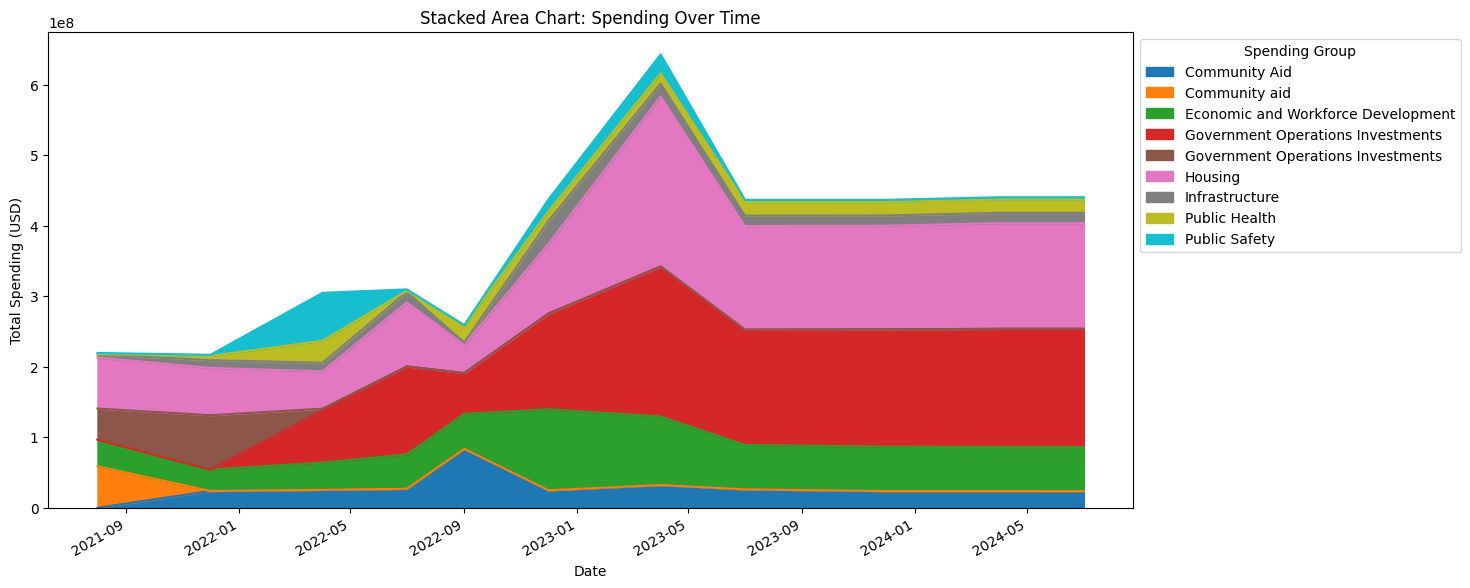

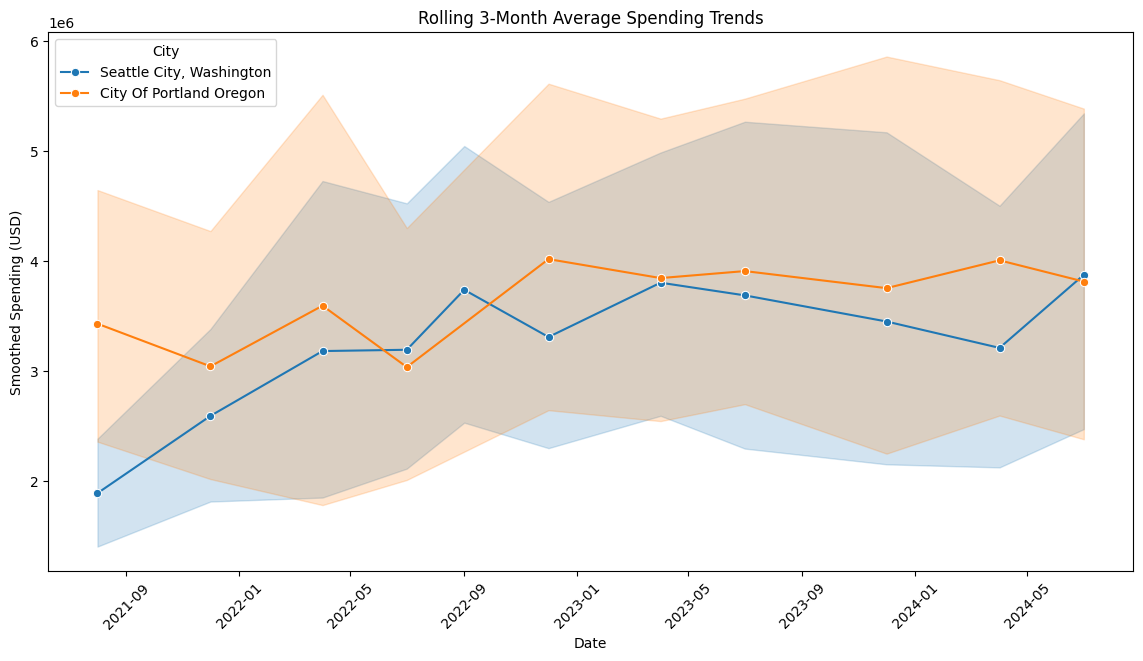

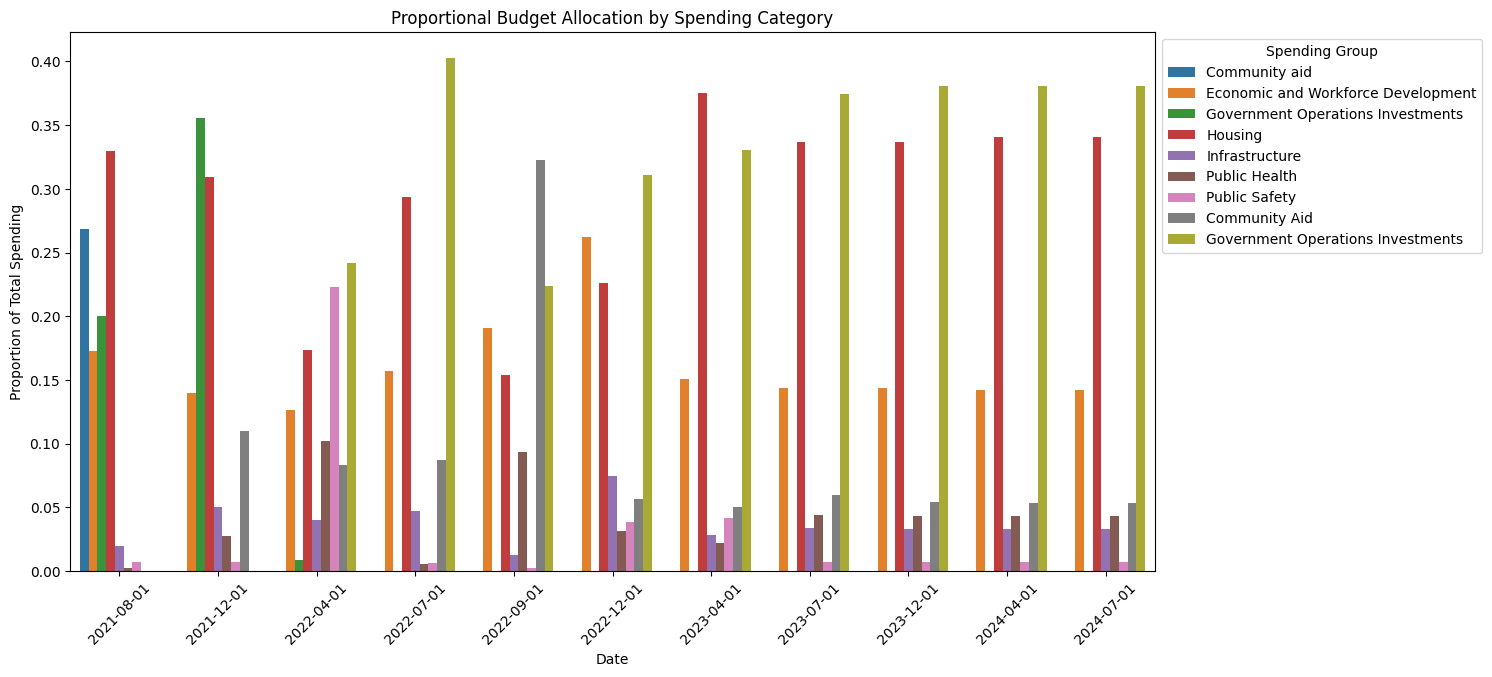

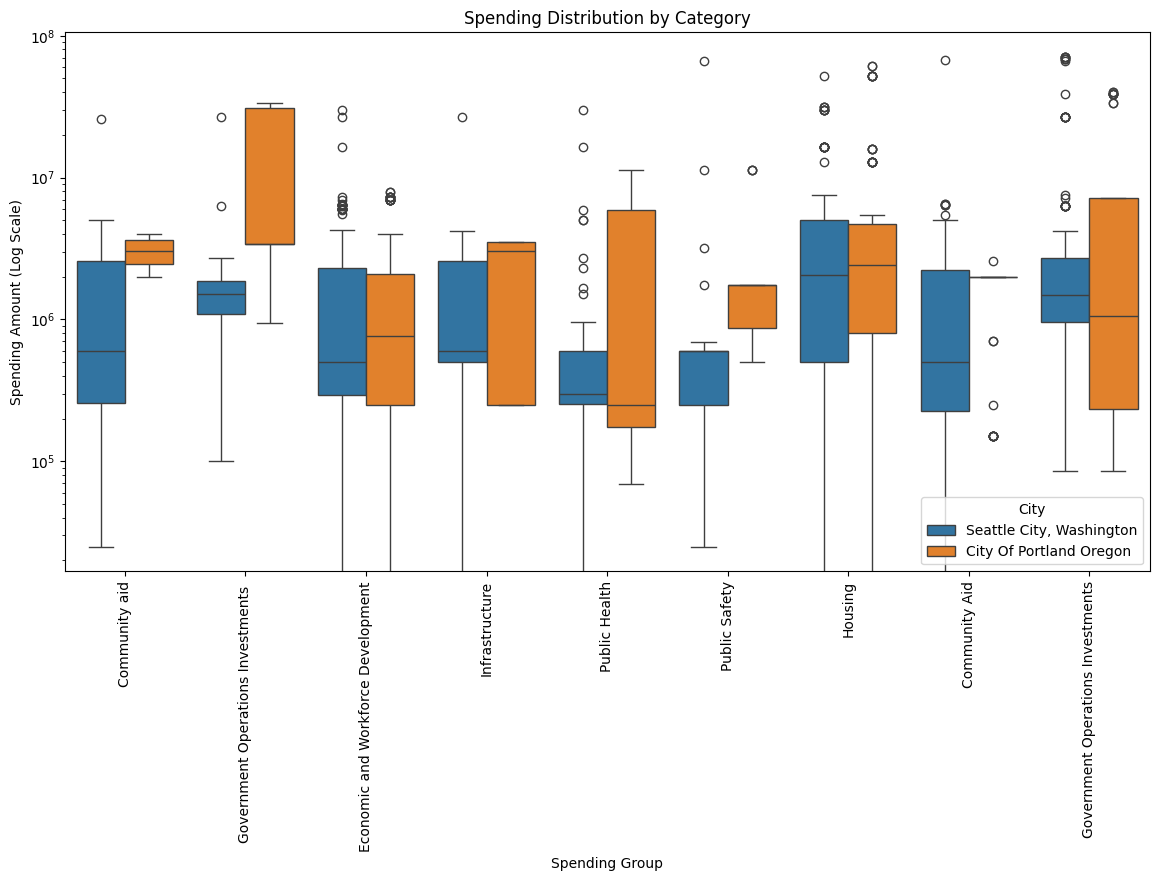

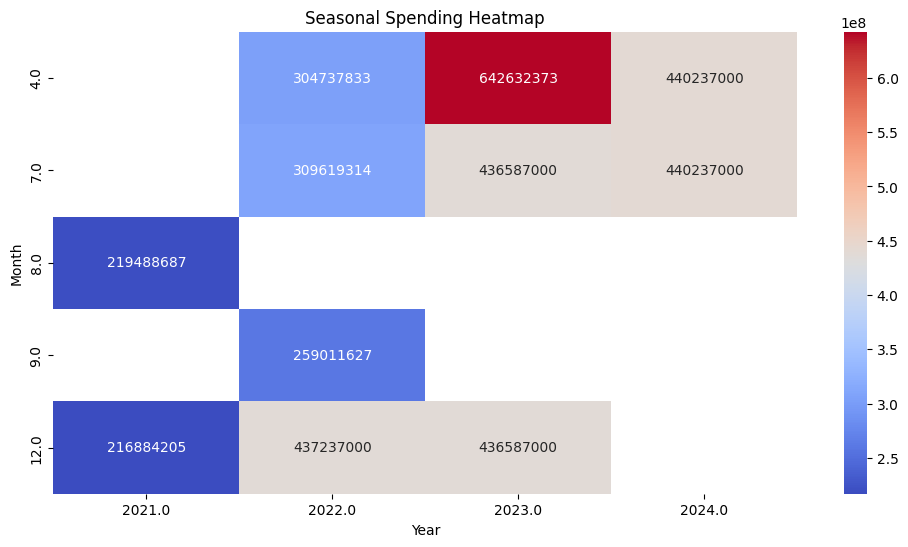

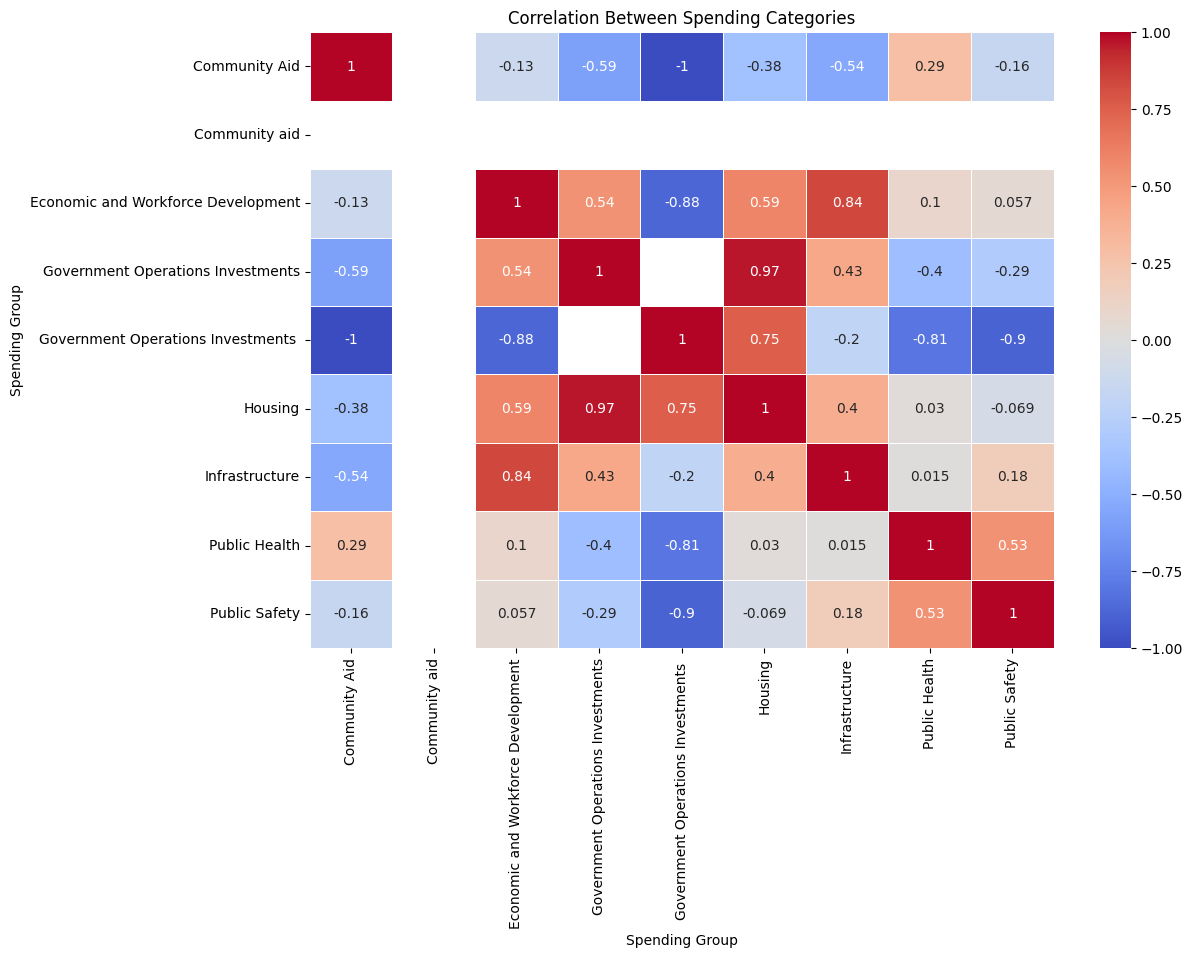

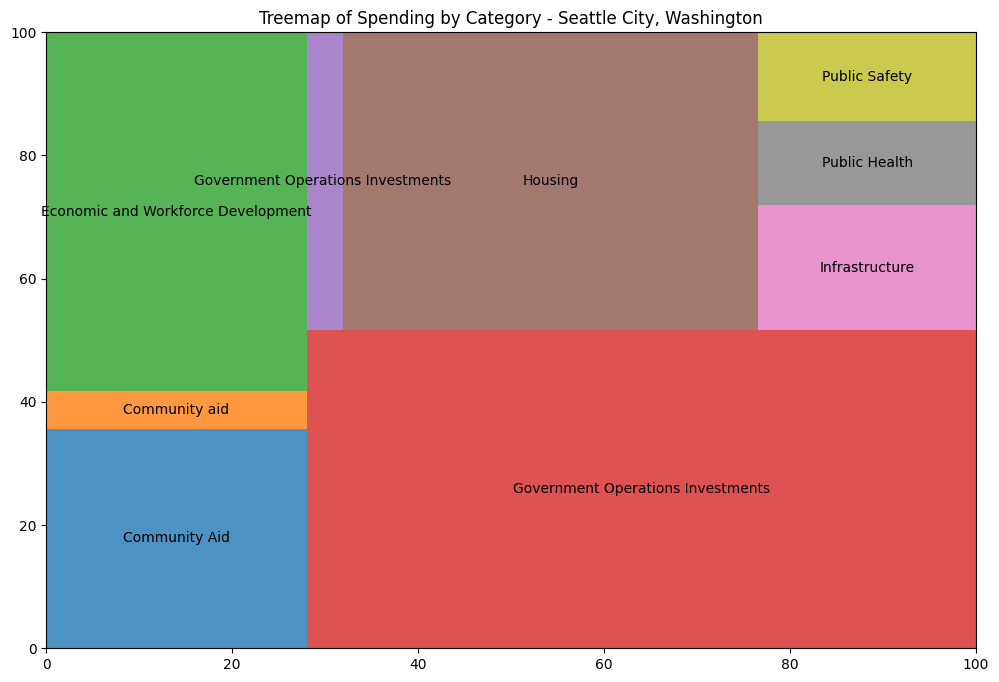

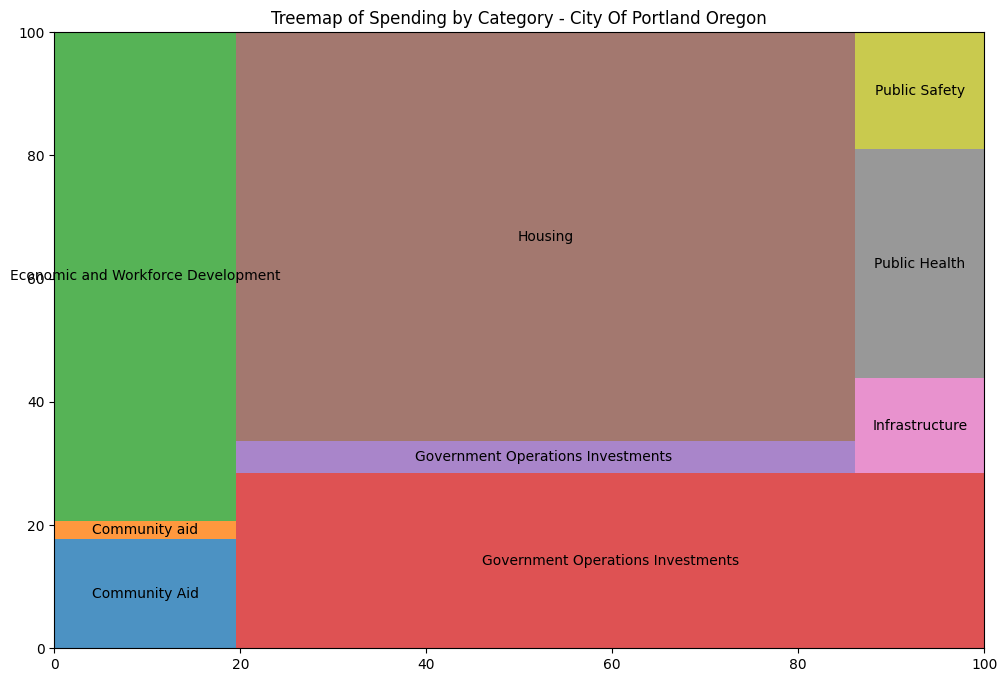

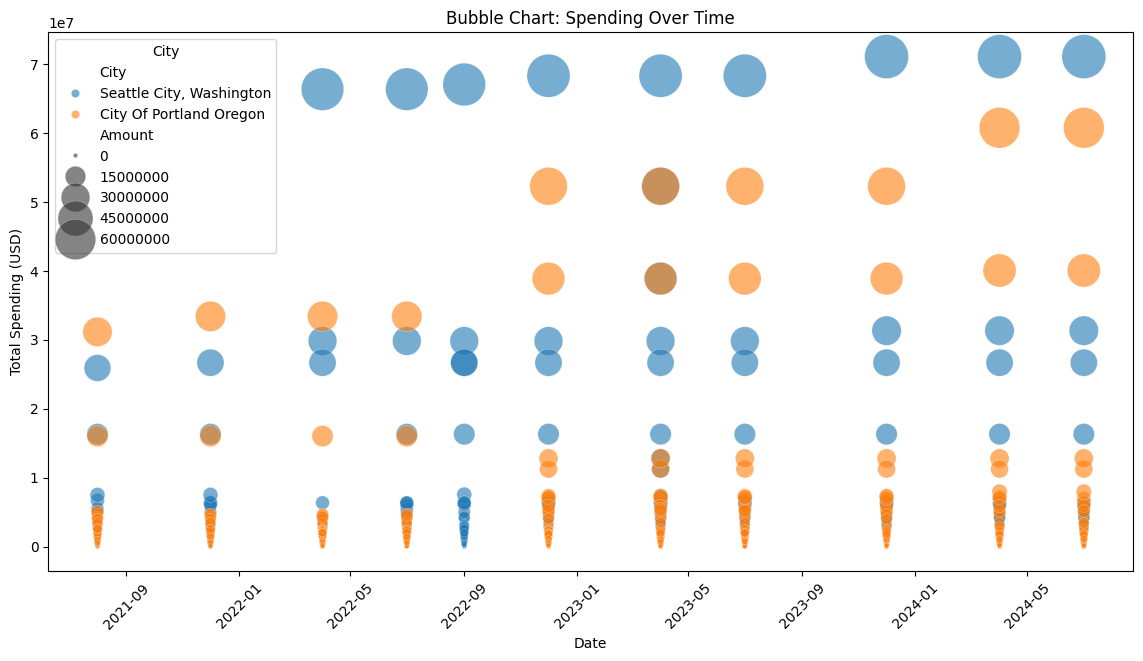

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Install squarify if not already installed
!pip install squarify  # This line installs the necessary package


# Load the dataset
file_path = '/content/Seattle Portland Time Series Data.V1.csv'
df = pd.read_csv(file_path)

# Convert 'Date' to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%b %Y', errors='coerce')

# Ensure 'Amount' is numeric
df['Amount'] = df['Amount'].replace({',': ''}, regex=True).astype(float)

# 1. Stacked Area Chart for Spending Over Time
plt.figure(figsize=(14, 7))
df_pivot = df.pivot_table(index='Date', columns='Spending Group', values='Amount', aggfunc='sum')
df_pivot.plot(kind='area', stacked=True, figsize=(14, 7), colormap='tab10')
plt.title('Stacked Area Chart: Spending Over Time')
plt.xlabel('Date')
plt.ylabel('Total Spending (USD)')
plt.legend(title='Spending Group', bbox_to_anchor=(1, 1))
plt.show()

# 2. Rolling Average Spending Trends
df['Rolling_Mean'] = df.groupby('City')['Amount'].transform(lambda x: x.rolling(3, min_periods=1).mean())
plt.figure(figsize=(14, 7))
sns.lineplot(data=df, x='Date', y='Rolling_Mean', hue='City', marker='o')
plt.title('Rolling 3-Month Average Spending Trends')
plt.xlabel('Date')
plt.ylabel('Smoothed Spending (USD)')
plt.xticks(rotation=45)
plt.legend(title='City')
plt.show()

# 3. Proportional Budget Allocation by Category
plt.figure(figsize=(14, 7))
df_grouped = df.groupby(['Date', 'Spending Group'])['Amount'].sum().reset_index()
df_total = df_grouped.groupby('Date')['Amount'].sum().reset_index()
df_merged = df_grouped.merge(df_total, on='Date', suffixes=('', '_Total'))
df_merged['Proportion'] = df_merged['Amount'] / df_merged['Amount_Total']
sns.barplot(data=df_merged, x='Date', y='Proportion', hue='Spending Group')
plt.title('Proportional Budget Allocation by Spending Category')
plt.xlabel('Date')
plt.ylabel('Proportion of Total Spending')
plt.xticks(rotation=45)
plt.legend(title='Spending Group', bbox_to_anchor=(1, 1))
plt.show()

# 4. Boxplots for Spending Distribution
plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='Spending Group', y='Amount', hue='City')
plt.xticks(rotation=90)
plt.yscale('log')
plt.title('Spending Distribution by Category')
plt.xlabel('Spending Group')
plt.ylabel('Spending Amount (Log Scale)')
plt.show()

# 5. Heatmap for Seasonal Spending Trends
df['Month'] = df['Date'].dt.month
# Extract the year from the 'Date' column and create a new 'Year' column
df['Year'] = df['Date'].dt.year
df_monthly = df.pivot_table(index='Month', columns='Year', values='Amount', aggfunc='sum')
plt.figure(figsize=(12, 6))
sns.heatmap(df_monthly, cmap='coolwarm', annot=True, fmt='.0f')
plt.title('Seasonal Spending Heatmap')
plt.xlabel('Year')
plt.ylabel('Month')
plt.show()

# 6. Correlation Matrix Between Spending Categories
df_corr = df.pivot_table(index='Date', columns='Spending Group', values='Amount', aggfunc='sum').corr()
plt.figure(figsize=(12, 8))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Between Spending Categories')
plt.show()

# 7. Treemap of Total Spending by Category (Seattle vs. Portland)
for city in ['Seattle City, Washington', 'City Of Portland Oregon']:
    city_df = df[df['City'] == city]
    category_totals = city_df.groupby('Spending Group')['Amount'].sum()
    plt.figure(figsize=(12, 8))
    colors = sns.color_palette('tab10', len(category_totals))  # Unique colors for each section
    squarify.plot(sizes=category_totals, label=category_totals.index, alpha=0.8, color=colors)
    plt.title(f'Treemap of Spending by Category - {city}')
    plt.show()

# 8. Bubble Chart for Spending Trends
plt.figure(figsize=(14, 7))
sns.scatterplot(data=df, x='Date', y='Amount', size='Amount', hue='City', sizes=(10, 1000), alpha=0.6)
plt.title('Bubble Chart: Spending Over Time')
plt.xlabel('Date')
plt.ylabel('Total Spending (USD)')
plt.xticks(rotation=45)
plt.legend(title='City')
plt.show()


,Date,City,Spending Group,Spending Subgroup,Treasury Spend Subgroup,Treausry Spend Group,Amount
546,NaT,"Seattle City, Washington",Government Operations Investments,Fiscal Health Recovery,Provision of Government Services,Revenue Replacement,71060771.89
547,NaT,"Seattle City, Washington",Government Operations Investments,Fiscal Health Recovery,Provision of Government Services,Revenue Replacement,26670000.00
548,NaT,"Seattle City, Washington",Housing,Homelessness,Long-Term Housing Security: Services for Unhou...,Negative Economic Impacts,29812968.00
549,NaT,"Seattle City, Washington",Housing,Affordable Housing,Long-Term Housing Security: Affordable Housing,Negative Economic Impacts,16300000.00
550,NaT,"Seattle City, Washington",Economic and Workforce Development,Youth Workforce Development,Economic Impact Assistance: Other,Negative Economic Impacts,6357890.88
...,...,...,...,...,...,...,...
1191,NaT,City Of Portland Oregon,Economic and Workforce Development,Small Business Support,Rehabilitation of Commercial Properties or Oth...,Negative Economic Impacts,75000.00
1192,NaT,City Of Portland Oregon,Economic and Workforce Development,Neighborhood/Downtown Revitalization,Economic Impact Assistance: Other,Negative Economic Impacts,40000.00
1193,NaT,City Of Portland Oregon,Economic and Workforce Development,Neighborhood/Downtown Revitalization,Economic Impact Assistance: Other,Negative Economic Impacts,0.00
1194,NaT,City Of Portland Oregon,Housing,Homelessness,Economic Impact Assistance: Other,Negative Economic Impacts,0.00


,0
Date,169
City,0
Spending Group,0
Spending Subgroup,0
Treasury Spend Subgroup,0
Treausry Spend Group,66
Amount,0


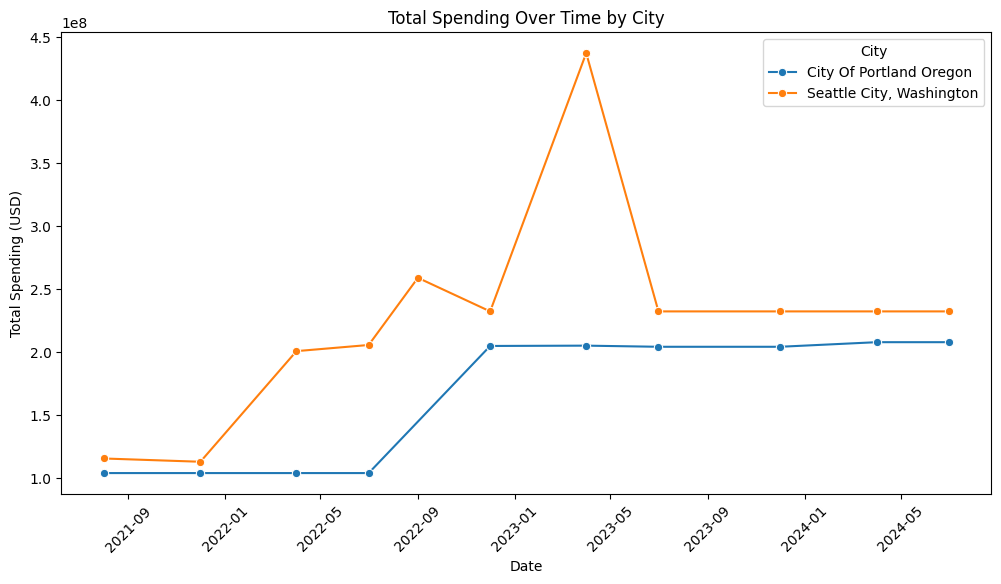

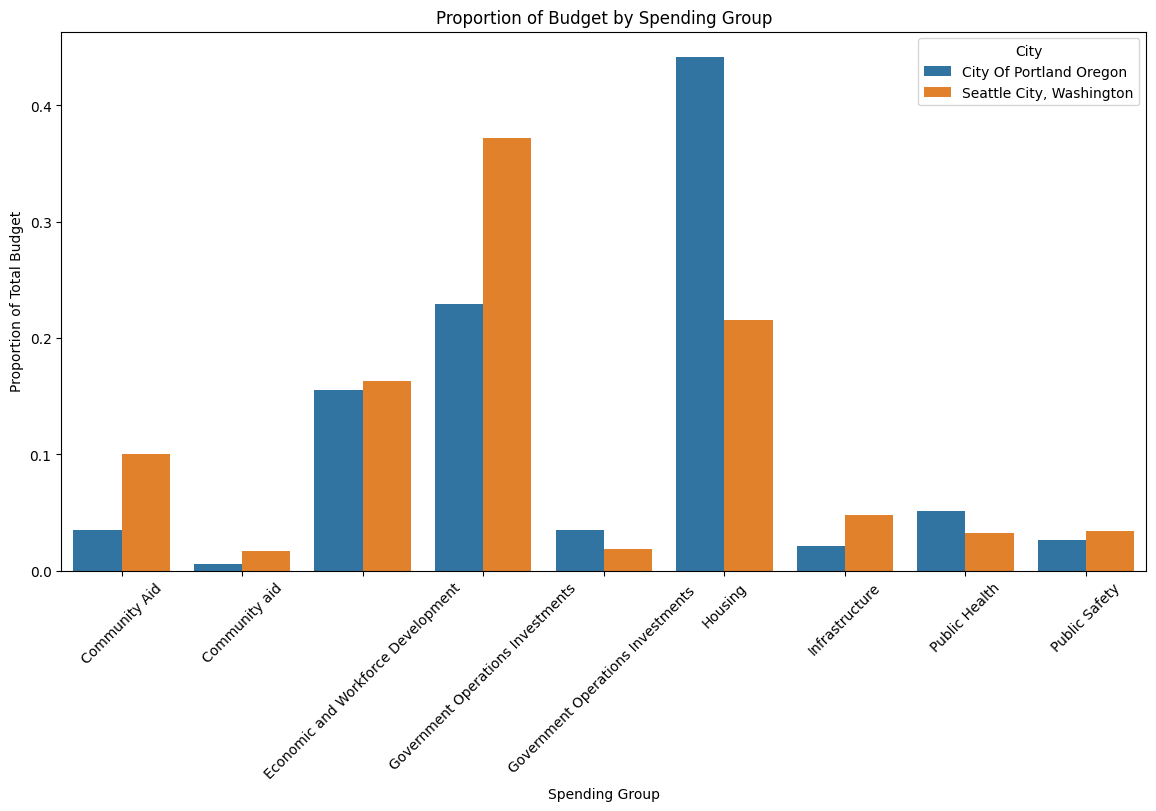

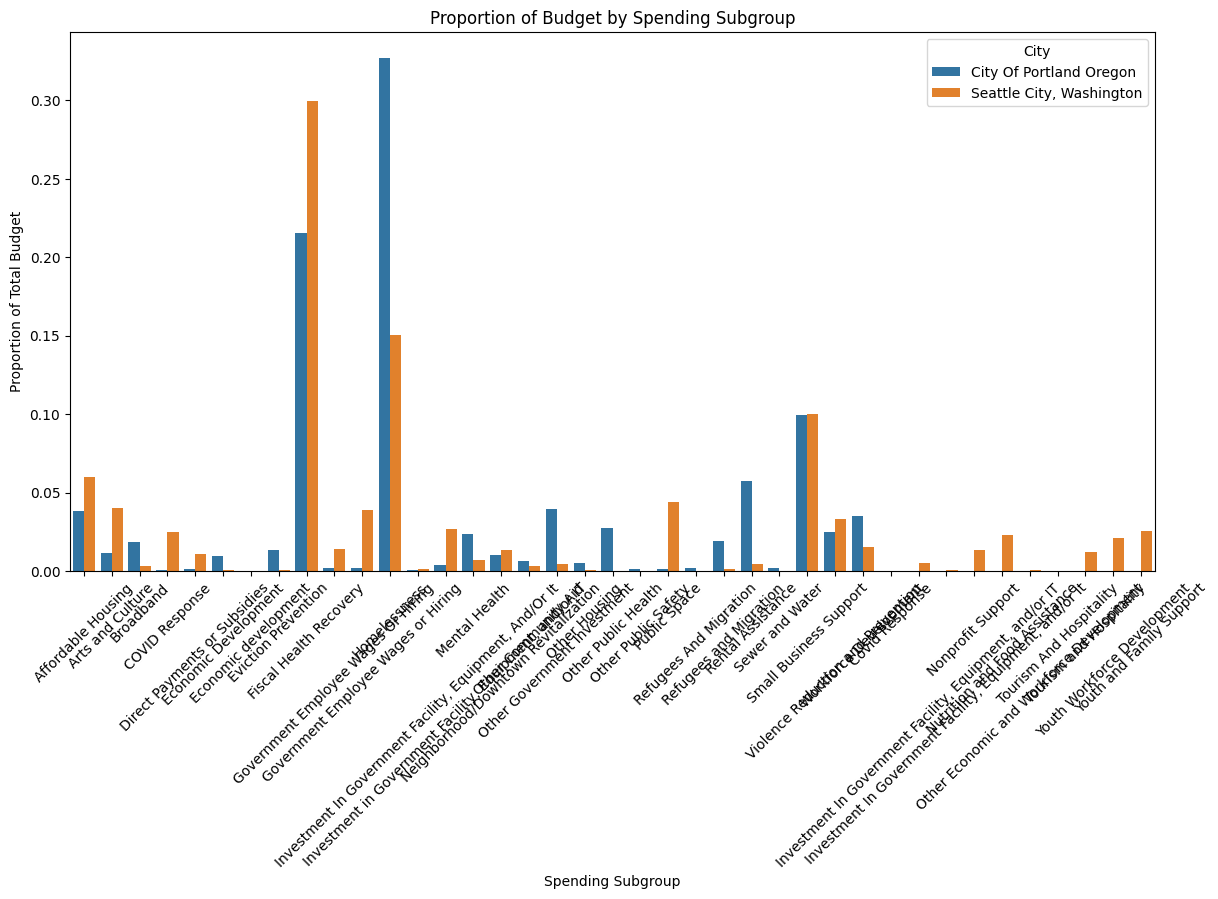

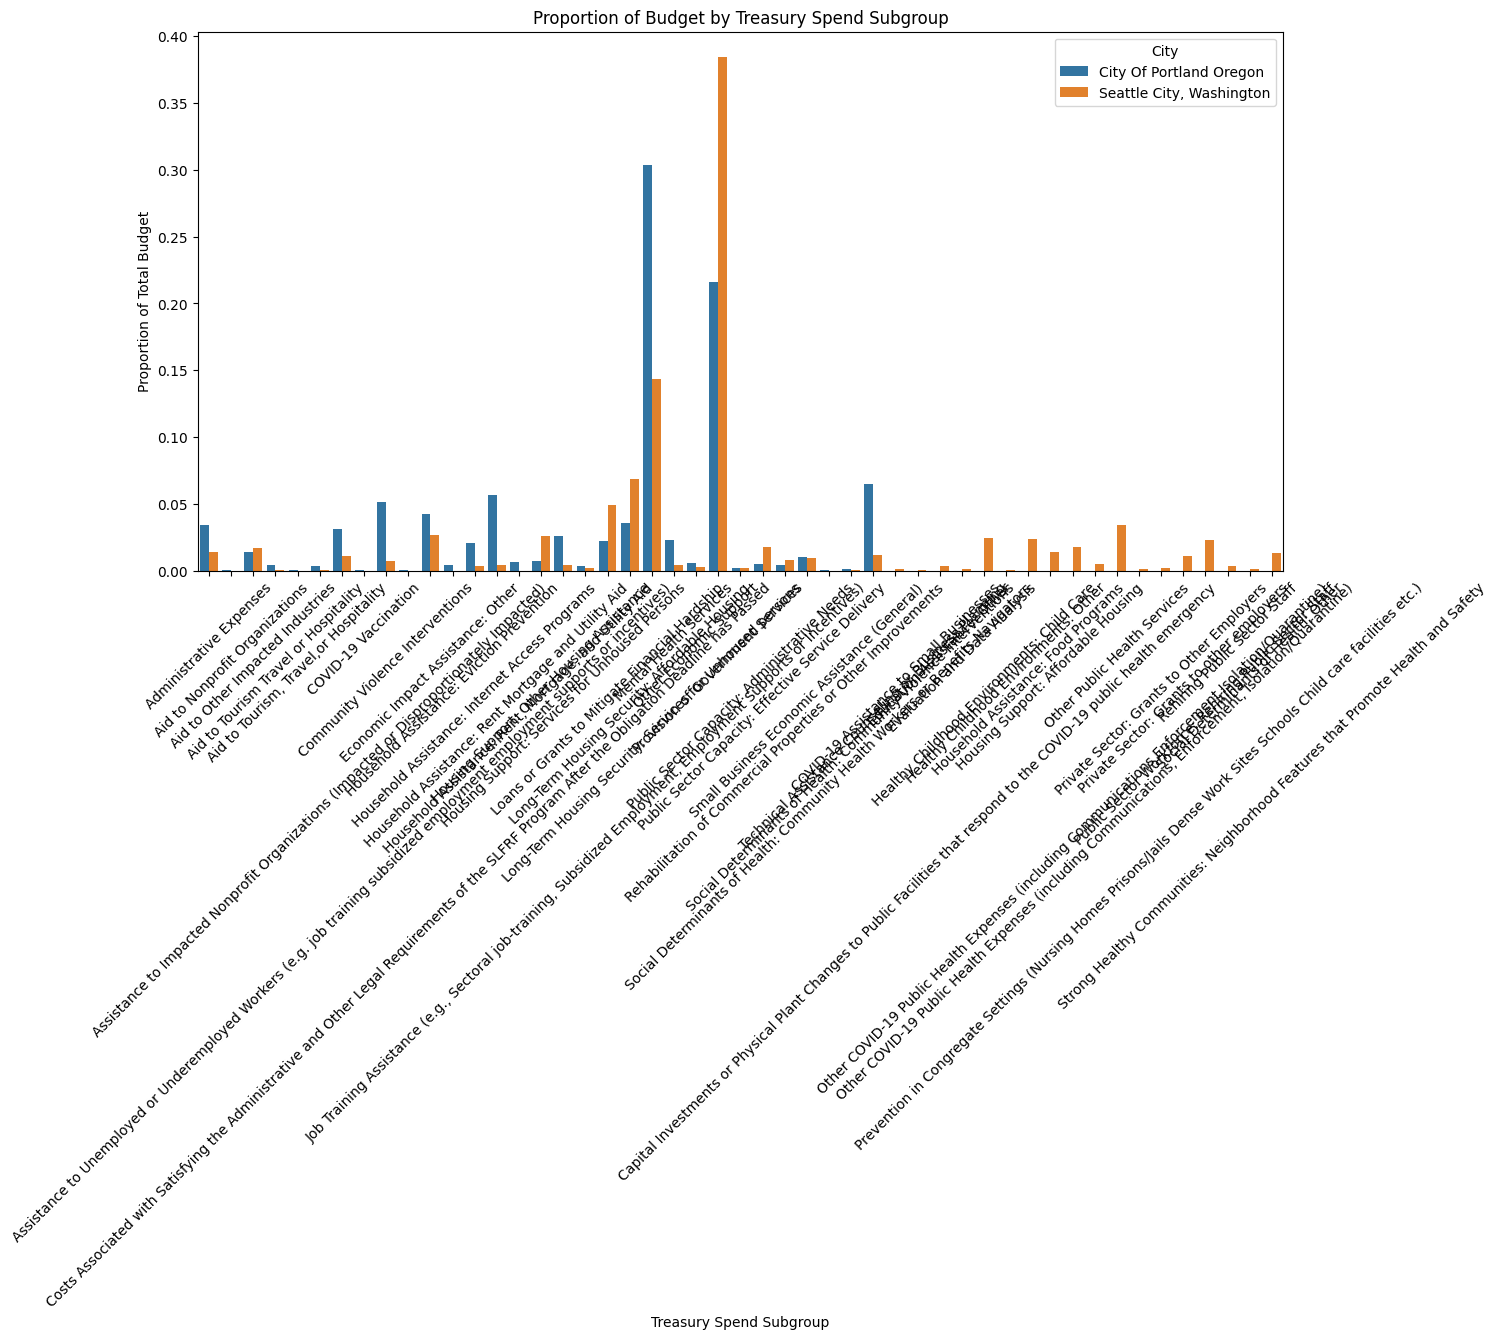

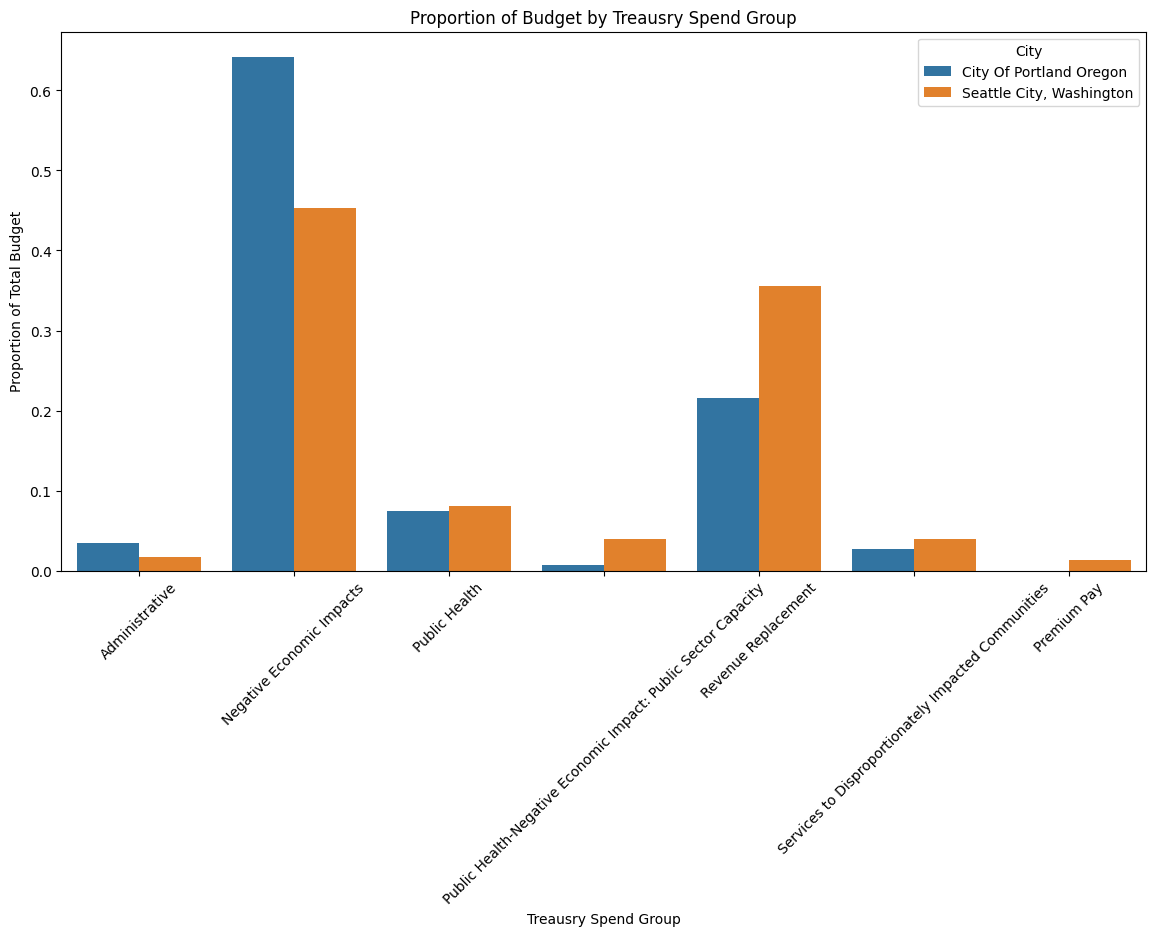

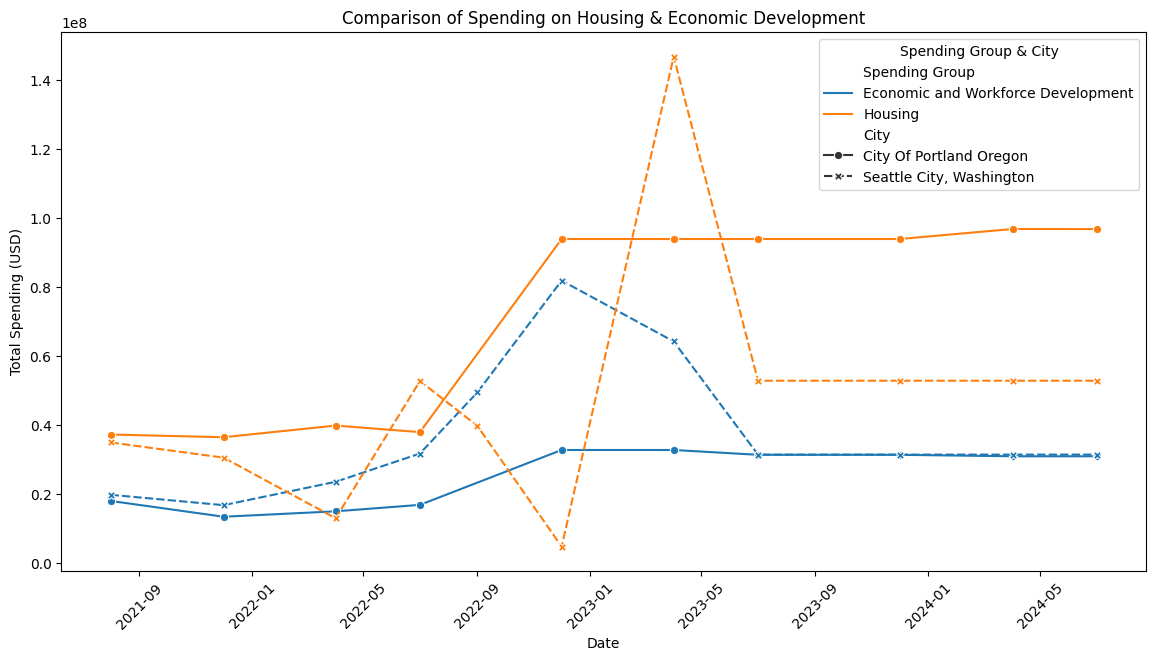

<ipython-input-2-d948162d0cf6>:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_spending.index, y=monthly_spending.values, palette='viridis')


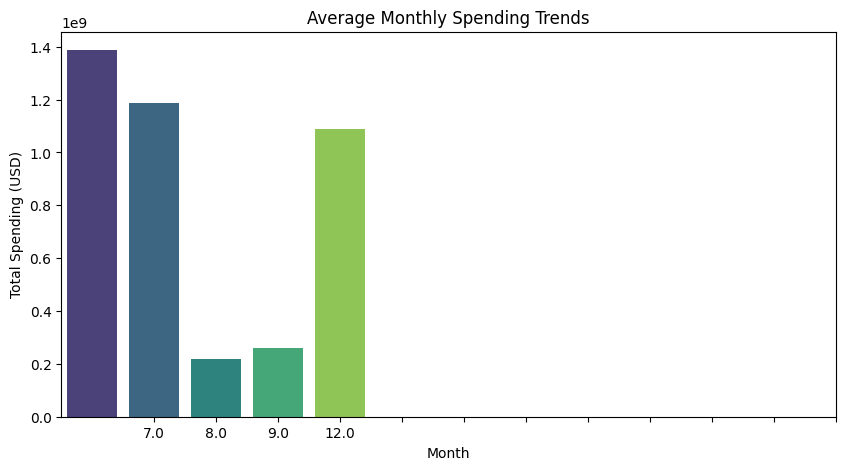

,Date,City,Spending Group,Spending Subgroup,Treasury Spend Subgroup,Treausry Spend Group,Amount
0,2021-08-01,"Seattle City, Washington",Community aid,Nonprofit Support,Aid to Nonprofit Organizations,Negative Economic Impacts,200000.00
1,2021-08-01,"Seattle City, Washington",Government Operations Investments,Other Government Investment,Evaluation and Data Analysis,Administrative,175000.00
2,2021-08-01,"Seattle City, Washington",Government Operations Investments,Other Government Investment,Evaluation and Data Analysis,Administrative,100000.00
3,2021-08-01,"Seattle City, Washington",Government Operations Investments,Government Employee Wages or Hiring,Rehiring Public Sector Staff,Negative Economic Impacts,1100000.00
4,2021-08-01,"Seattle City, Washington",Community aid,Other Community Aid,Evaluation and Data Analysis,Administrative,225000.00
...,...,...,...,...,...,...,...
1351,2024-07-01,City Of Portland Oregon,Community Aid,Other Community Aid,Social Determinants of Health: Community Healt...,Negative Economic Impacts,150000.00
1352,2024-07-01,City Of Portland Oregon,Public Safety,Other Public Safety,Aid to Tourism Travel or Hospitality,Negative Economic Impacts,500000.00
1353,2024-07-01,City Of Portland Oregon,Economic and Workforce Development,Economic Development,Economic Impact Assistance: Other,Negative Economic Impacts,144429.27
1354,2024-07-01,City Of Portland Oregon,Economic and Workforce Development,Economic Development,Economic Impact Assistance: Other,Negative Economic Impacts,1125000.00


In [ ]:
from IPython import get_ipython
from IPython.display import display

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset (assuming it is uploaded to Google Colab)
file_path = '/content/Seattle Portland Time Series Data.V1.csv'
df = pd.read_csv(file_path)

# Standardizing Month Abbreviations
month_corrections = {
    "Sept": "Sep"
}
df['Date'] = df['Date'].replace(month_corrections, regex=True)

# Convert 'Date' to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%b %Y', errors='coerce')

# Display rows with parsing errors
if df['Date'].isnull().sum() > 0:
    print("Warning: Some date values could not be converted. Check for inconsistencies.")
    display(df[df['Date'].isnull()])

# Ensure 'Amount' is numeric
df['Amount'] = df['Amount'].replace({',': ''}, regex=True).astype(float)

# Check for missing values
display(df.isnull().sum())

# Aggregate total spending by city over time
city_spending = df.groupby(['Date', 'City'])['Amount'].sum().reset_index()

# Plot total spending trends over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=city_spending, x='Date', y='Amount', hue='City', marker='o')
plt.title('Total Spending Over Time by City')
plt.xlabel('Date')
plt.ylabel('Total Spending (USD)')
plt.xticks(rotation=45)
plt.legend(title='City')
plt.show()

# Calculate and visualize proportions of budget by city and program
program_groups = ['Spending Group', 'Spending Subgroup', 'Treasury Spend Subgroup', 'Treausry Spend Group']

for group in program_groups:
    group_spending = df.groupby(['City', group])['Amount'].sum().reset_index()
    group_total = group_spending.groupby('City')['Amount'].sum().reset_index()
    group_spending = group_spending.merge(group_total, on='City', suffixes=('', '_Total'))
    group_spending['Proportion'] = group_spending['Amount'] / group_spending['Amount_Total']
    plt.figure(figsize=(14, 7))
    sns.barplot(data=group_spending, x=group, y='Proportion', hue='City')
    plt.title(f'Proportion of Budget by {group}')
    plt.xlabel(group)
    plt.ylabel('Proportion of Total Budget')
    plt.xticks(rotation=45)
    plt.legend(title='City')
    plt.show()

# Compare spending on key categories (e.g., Housing and Economic Development)
key_categories = ['Housing', 'Economic and Workforce Development']
filtered_df = df[df['Spending Group'].isin(key_categories)]
category_city_spending = filtered_df.groupby(['Date', 'City', 'Spending Group'])['Amount'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=category_city_spending, x='Date', y='Amount', hue='Spending Group', style='City', markers=True)
plt.title('Comparison of Spending on Housing & Economic Development')
plt.xlabel('Date')
plt.ylabel('Total Spending (USD)')
plt.xticks(rotation=45)
plt.legend(title='Spending Group & City', bbox_to_anchor=(1, 1))
plt.show()

# Identify seasonal spending patterns
monthly_spending = df.groupby(df['Date'].dt.month)['Amount'].sum()

plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_spending.index, y=monthly_spending.values, palette='viridis')
plt.title('Average Monthly Spending Trends')
plt.xlabel('Month')
plt.ylabel('Total Spending (USD)')
plt.xticks(range(1, 13))
plt.show()

# Display final cleaned dataset
# Instead of using ace_tools, we use the IPython display function
display(df) # Display the DataFrame using the display function")}]}


# New Section

<ipython-input-6-51d43a543c78>:52: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


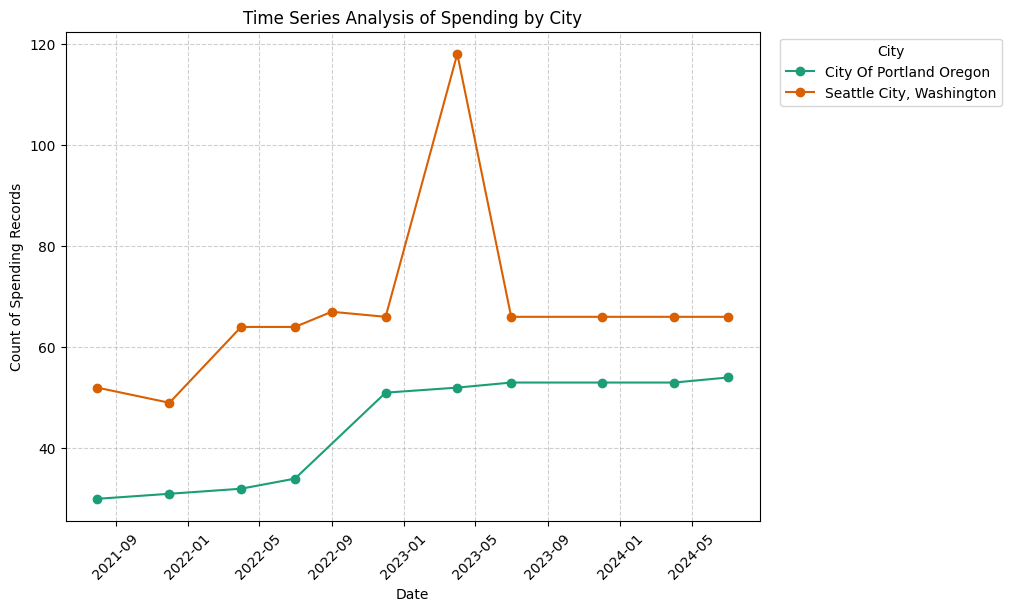

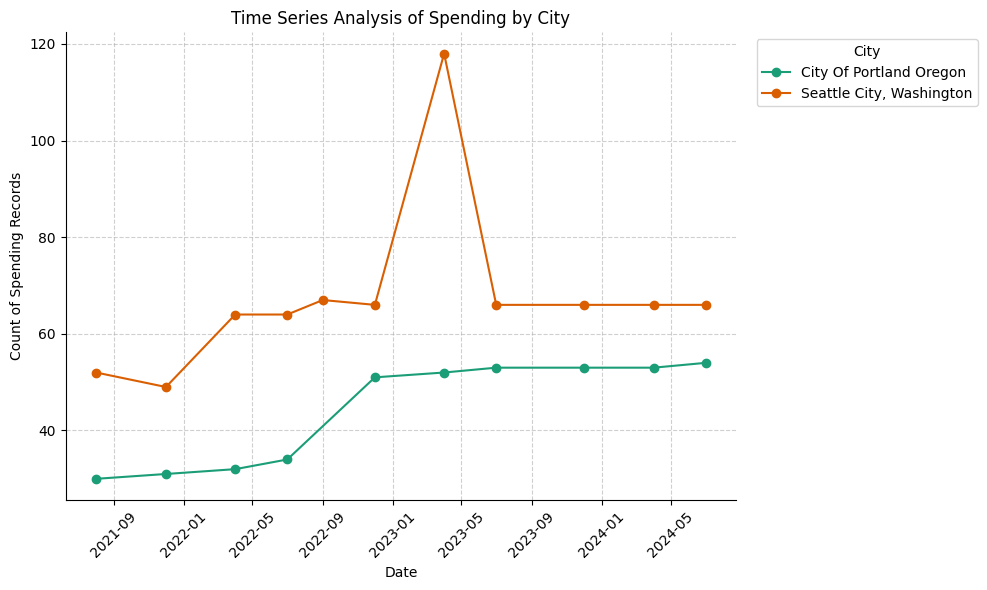

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

def _plot_series(series, series_name, series_index=0):
    palette = list(sns.palettes.mpl_palette('Dark2'))
    counted = (series['Date']
                  .value_counts()
                  .reset_index(name='counts')
                  .rename({'index': 'Date'}, axis=1)
                  .sort_values('Date', ascending=True))
    xs = counted['Date']
    ys = counted['counts']
    plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)], marker='o')

fig, ax = plt.subplots(figsize=(10, 6), layout='constrained')
df_sorted = df.sort_values('Date', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('City')):
    _plot_series(series, series_name, i)

plt.title('Time Series Analysis of Spending by City')
plt.xlabel('Date')
plt.ylabel('Count of Spending Records')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='City', bbox_to_anchor=(1.02, 1), loc='upper left')
from matplotlib import pyplot as plt
import seaborn as sns

def _plot_series(series, series_name, series_index=0):
    palette = list(sns.palettes.mpl_palette('Dark2'))
    counted = (series['Date']
                  .value_counts()
                  .reset_index(name='counts')
                  .rename({'index': 'Date'}, axis=1)
                  .sort_values('Date', ascending=True))
    xs = counted['Date']
    ys = counted['counts']
    plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)], marker='o')

fig, ax = plt.subplots(figsize=(10, 6), layout='constrained')
df_sorted = df.sort_values('Date', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('City')):
    _plot_series(series, series_name, i)

plt.title('Time Series Analysis of Spending by City')
plt.xlabel('Date')
plt.ylabel('Count of Spending Records')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='City', bbox_to_anchor=(1.02, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.tight_layout()
plt.show()

<ipython-input-8-6bb44b591da7>:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


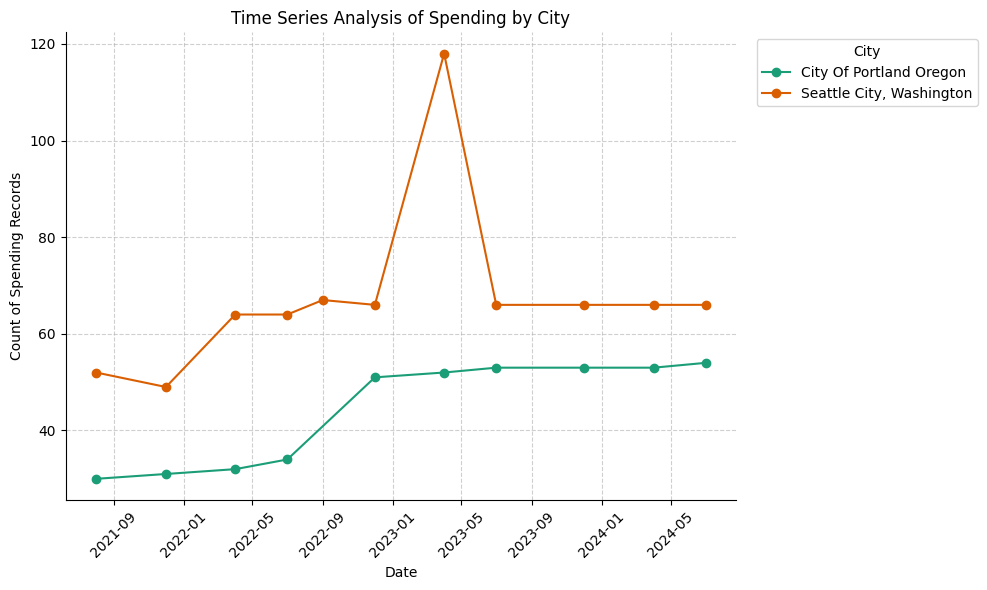

<ipython-input-8-6bb44b591da7>:62: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


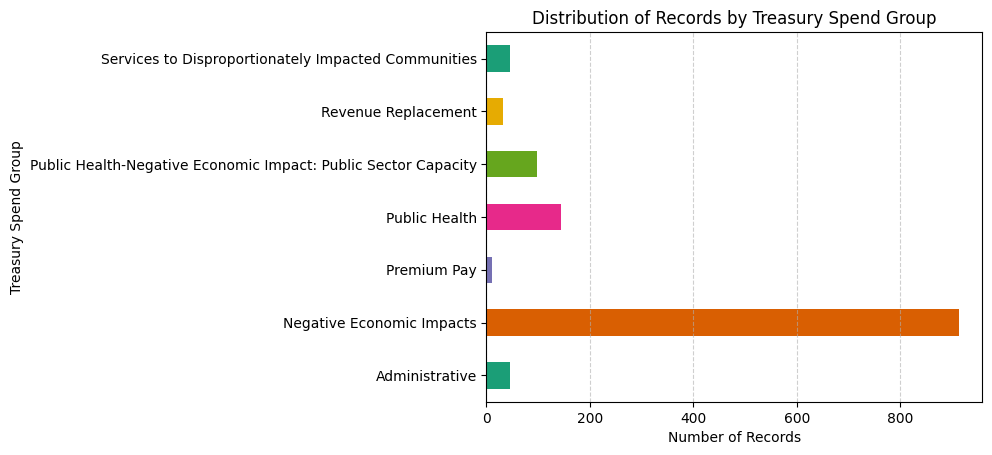

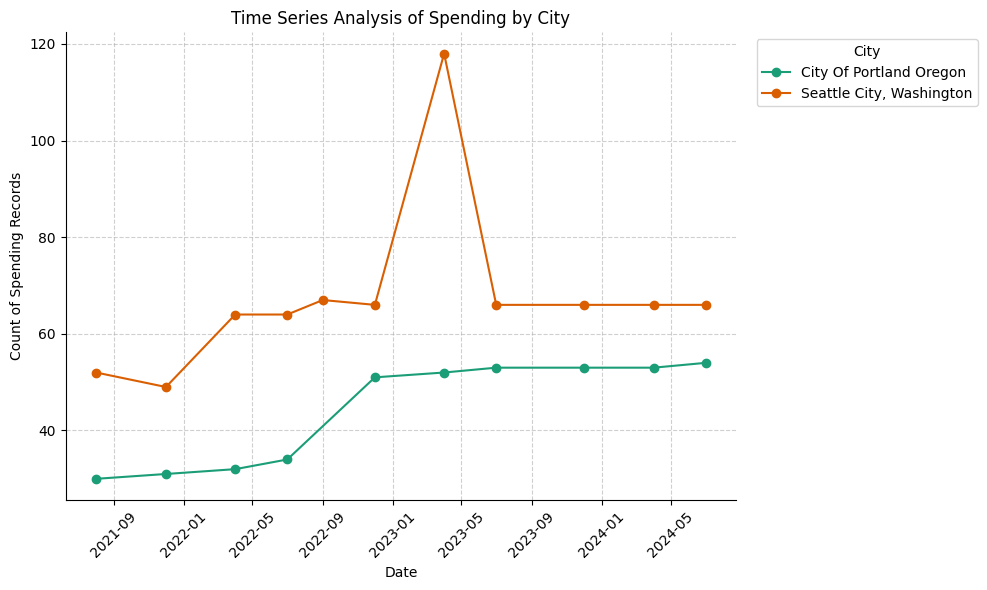

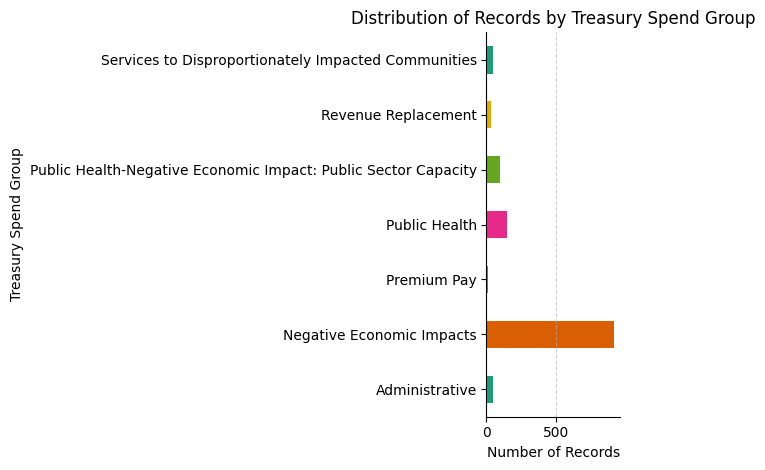

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

def _plot_series(series, series_name, series_index=0):
    palette = list(sns.palettes.mpl_palette('Dark2'))
    counted = (series['Date']
                  .value_counts()
                  .reset_index(name='counts')
                  .rename({'index': 'Date'}, axis=1)
                  .sort_values('Date', ascending=True))
    xs = counted['Date']
    ys = counted['counts']
    plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)], marker='o')

fig, ax = plt.subplots(figsize=(10, 6), layout='constrained')
df_sorted = df.sort_values('Date', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('City')):
    _plot_series(series, series_name, i)

plt.title('Time Series Analysis of Spending by City')
plt.xlabel('Date')
plt.ylabel('Count of Spending Records')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='City', bbox_to_anchor=(1.02, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.tight_layout()
plt.show()

# Enhanced bar chart for Treasury Spend Group
df.groupby('Treausry Spend Group').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.title('Distribution of Records by Treasury Spend Group')
plt.xlabel('Number of Records')
plt.ylabel('Treasury Spend Group')
plt.grid(axis='x', linestyle='--', alpha=0.6)
from matplotlib import pyplot as plt
import seaborn as sns

def _plot_series(series, series_name, series_index=0):
    palette = list(sns.palettes.mpl_palette('Dark2'))
    counted = (series['Date']
                  .value_counts()
                  .reset_index(name='counts')
                  .rename({'index': 'Date'}, axis=1)
                  .sort_values('Date', ascending=True))
    xs = counted['Date']
    ys = counted['counts']
    plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)], marker='o')

fig, ax = plt.subplots(figsize=(10, 6), layout='constrained')
df_sorted = df.sort_values('Date', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('City')):
    _plot_series(series, series_name, i)

plt.title('Time Series Analysis of Spending by City')
plt.xlabel('Date')
plt.ylabel('Count of Spending Records')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='City', bbox_to_anchor=(1.02, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.tight_layout()
plt.show()

# Enhanced bar chart for Treasury Spend Group
df.groupby('Treausry Spend Group').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.title('Distribution of Records by Treasury Spend Group')
plt.xlabel('Number of Records')
plt.ylabel('Treasury Spend Group')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

<ipython-input-3-1467064ba4b7>:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
<ipython-input-3-1467064ba4b7>:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


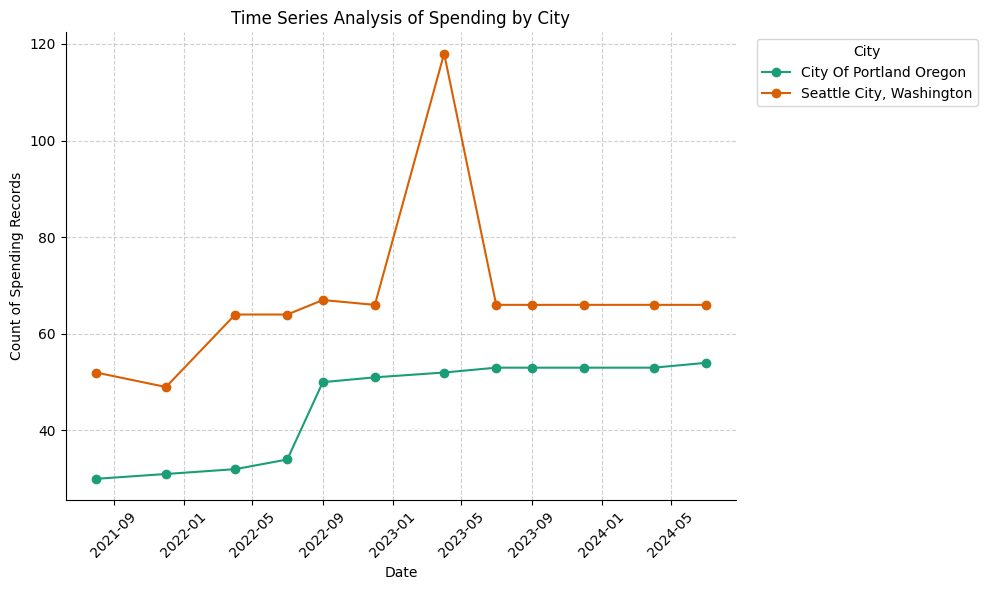

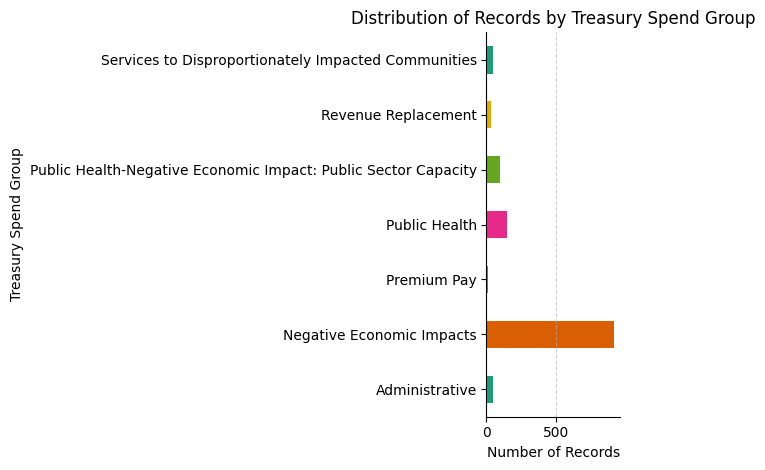

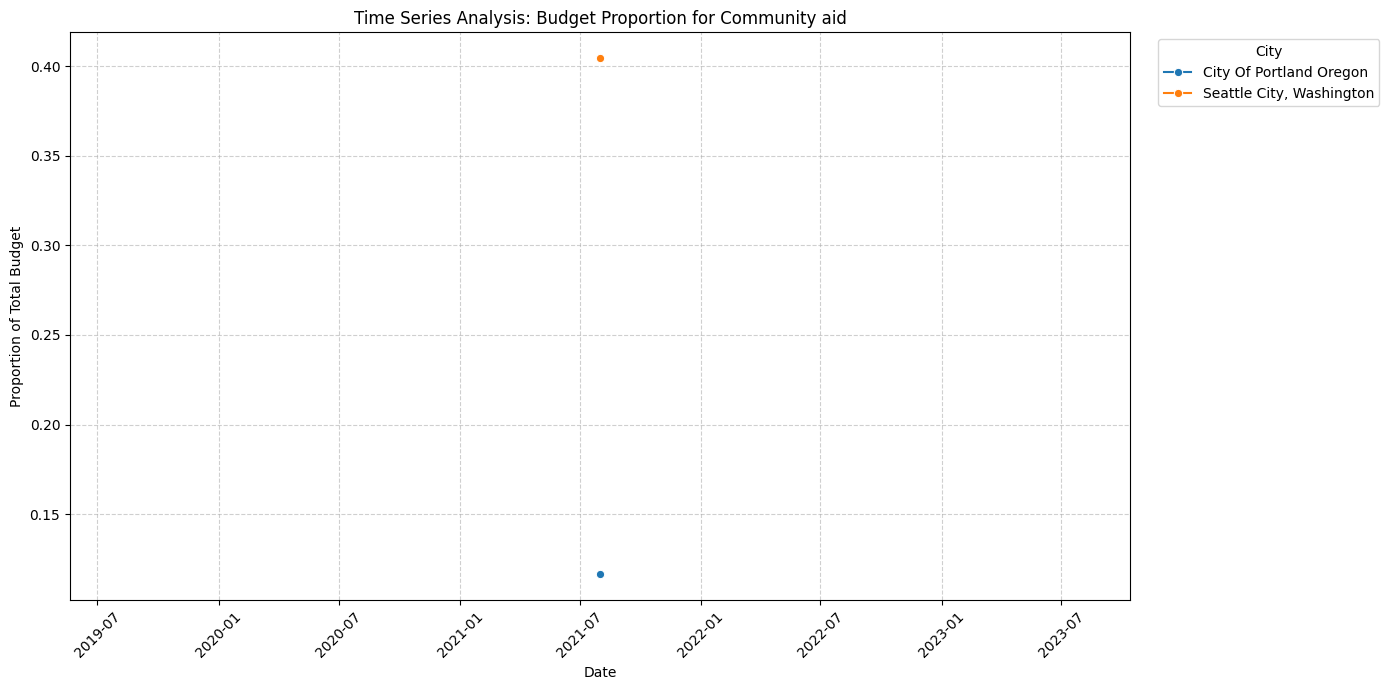

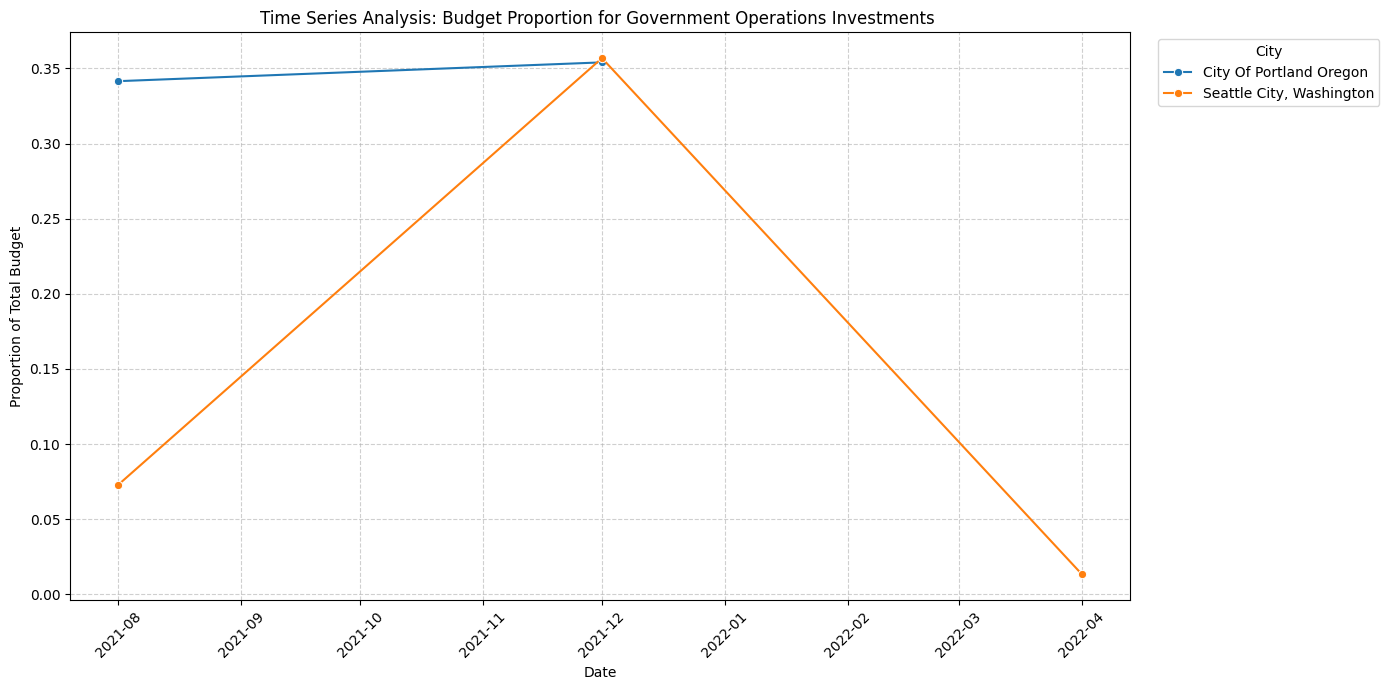

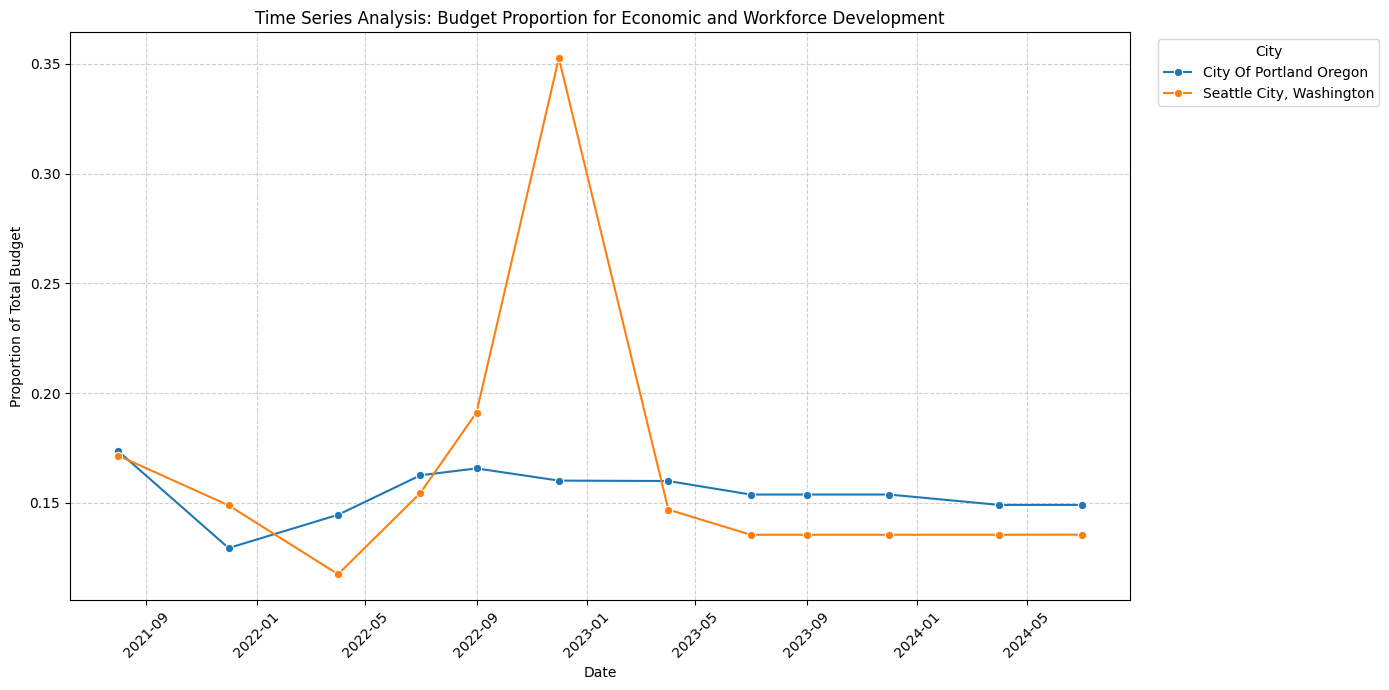

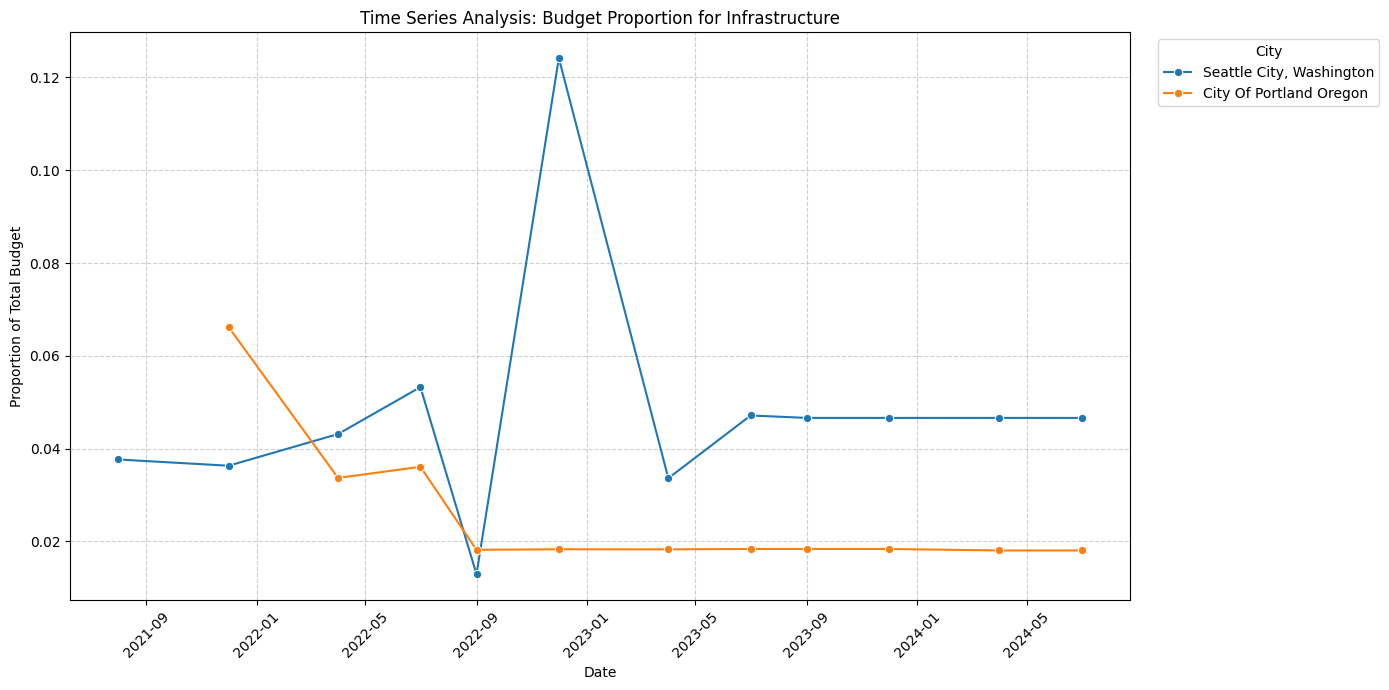

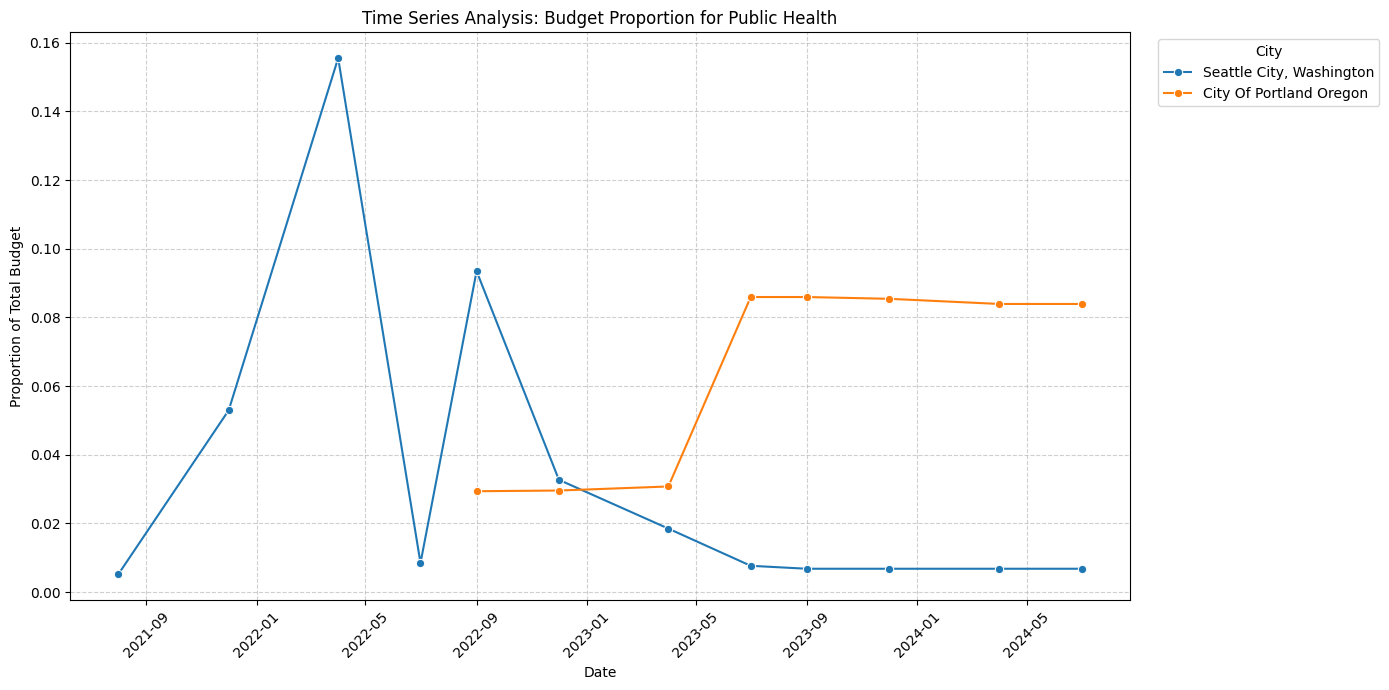

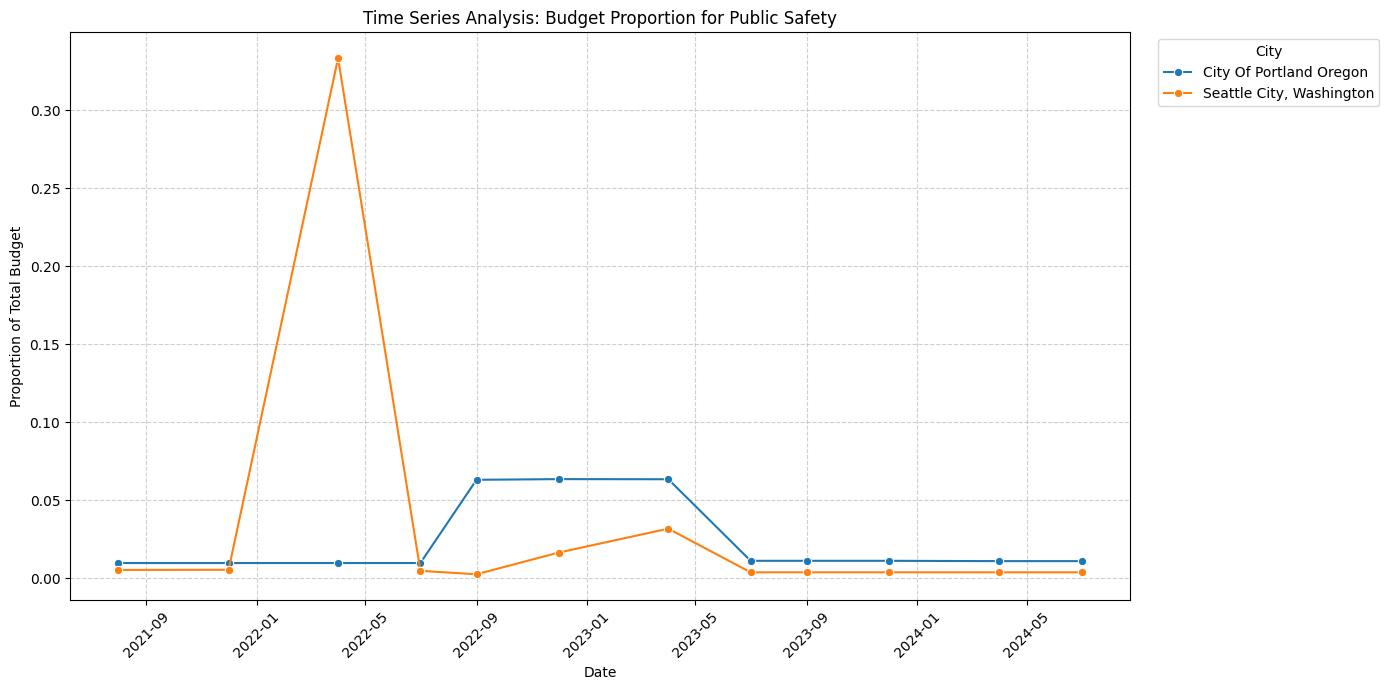

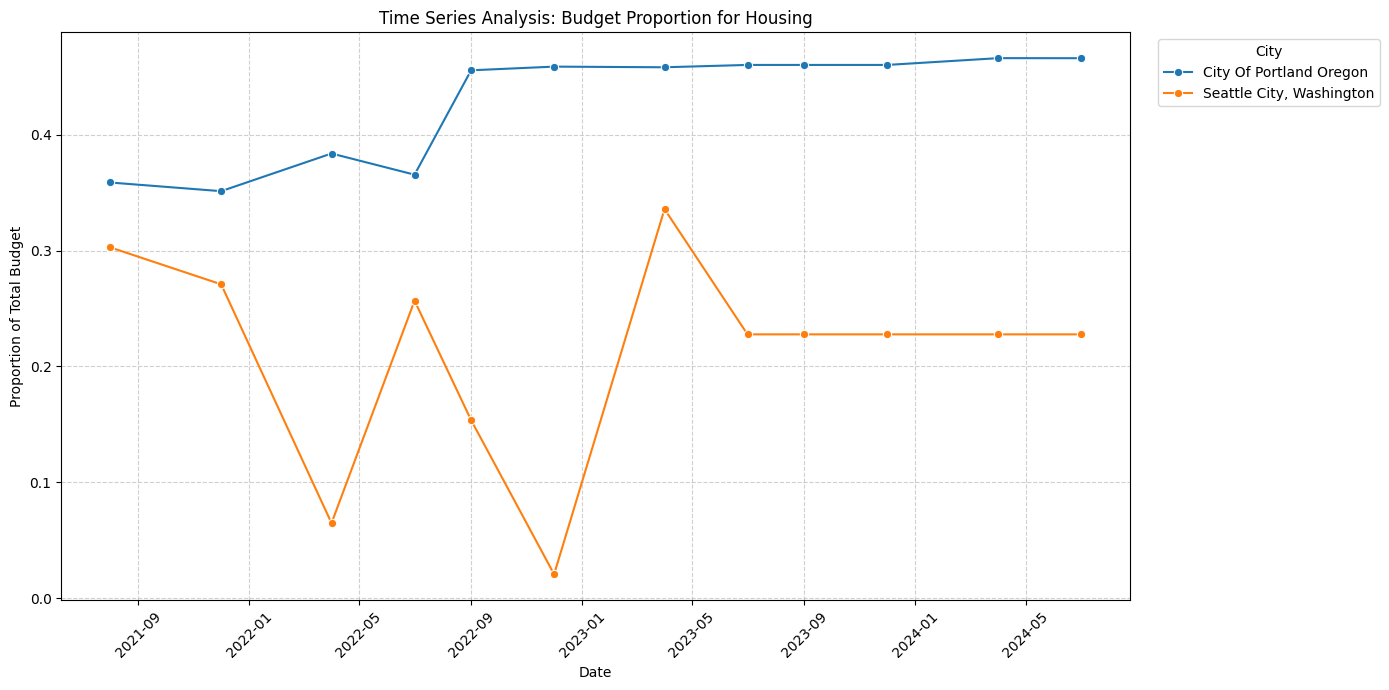

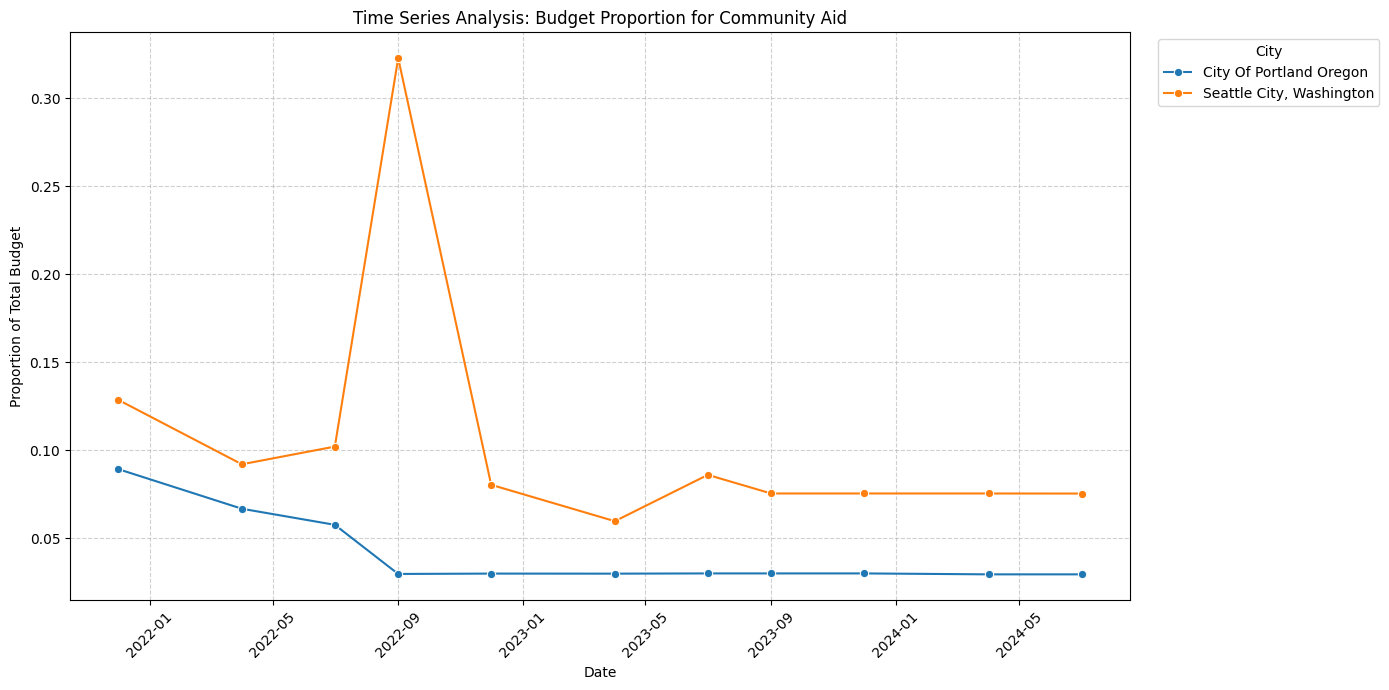

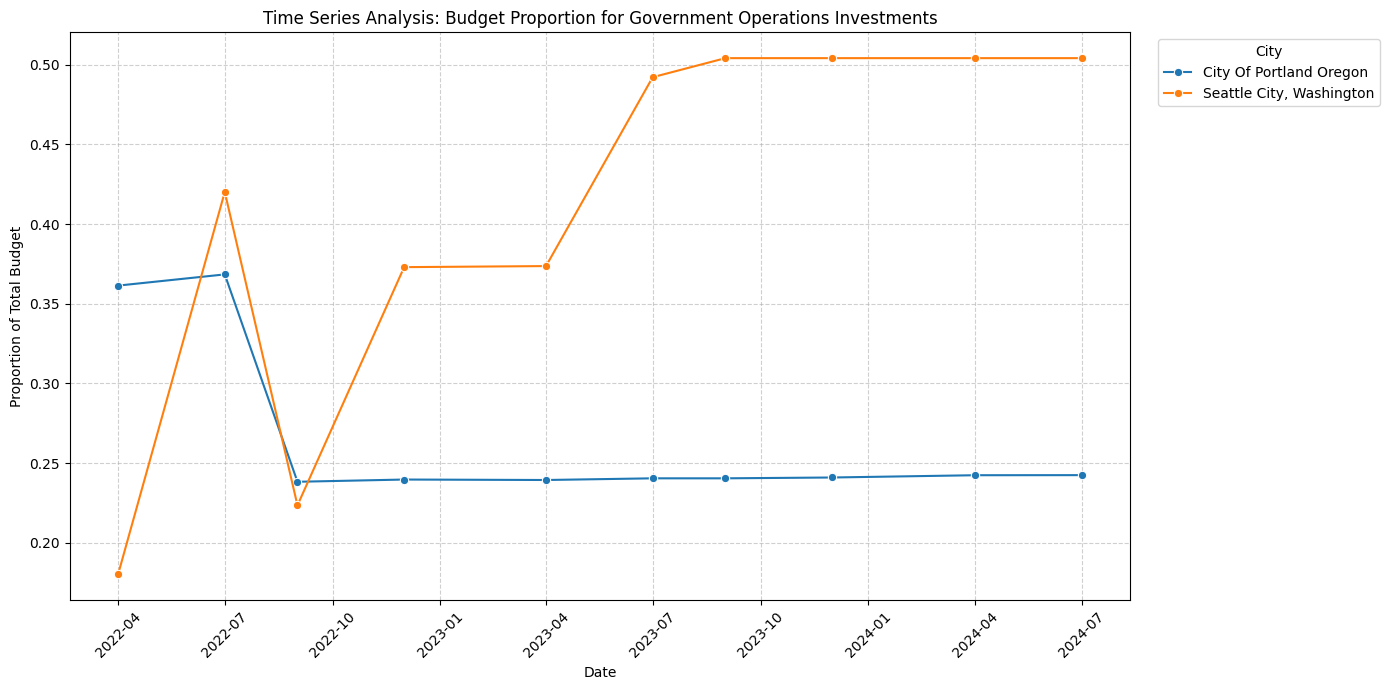

In [3]:
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd

# Load the dataset
file_path = '/content/Seattle Portland Time Series Data.V1.csv'
df = pd.read_csv(file_path)

# Convert 'Date' to datetime format with mixed format handling
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

def _plot_series(series, series_name, series_index=0):
    palette = list(sns.palettes.mpl_palette('Dark2'))
    counted = (series['Date']
                  .value_counts()
                  .reset_index(name='counts')
                  .rename({'index': 'Date'}, axis=1)
                  .sort_values('Date'))
    xs = counted['Date']
    ys = counted['counts']
    plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)], marker='o')

fig, ax = plt.subplots(figsize=(10, 6), layout='constrained')
df_sorted = df.sort_values('Date')
for i, (series_name, series) in enumerate(df_sorted.groupby('City')):
    _plot_series(series, series_name, i)

plt.title('Time Series Analysis of Spending by City')
plt.xlabel('Date')
plt.ylabel('Count of Spending Records')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='City', bbox_to_anchor=(1.02, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.tight_layout()
plt.show()

# Enhanced bar chart for Treasury Spend Group
df.groupby('Treausry Spend Group').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.title('Distribution of Records by Treasury Spend Group')
plt.xlabel('Number of Records')
plt.ylabel('Treasury Spend Group')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# Time Series Analysis for Budget Proportions
program_groups = df['Spending Group'].unique()

for group in program_groups:
    group_df = df[df['Spending Group'] == group]
    proportion_df = group_df.groupby(['Date', 'City'])['Amount'].sum().reset_index()
    total_df = df.groupby(['Date', 'City'])['Amount'].sum().reset_index()
    merged_df = proportion_df.merge(total_df, on=['Date', 'City'], suffixes=('_program', '_total'))
    merged_df['Proportion'] = merged_df['Amount_program'] / merged_df['Amount_total']

    merged_df = merged_df.sort_values('Date')

    plt.figure(figsize=(14, 7))
    sns.lineplot(data=merged_df, x='Date', y='Proportion', hue='City', marker='o')
    plt.title(f'Time Series Analysis: Budget Proportion for {group}')
    plt.xlabel('Date')
    plt.ylabel('Proportion of Total Budget')
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='City', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()